<a href="https://colab.research.google.com/github/faisu6339-glitch/Machine-learning/blob/main/Revision(Supervised_ML_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [196]:
import pandas as pd
import numpy as np

In [197]:
df=pd.read_csv('ds_salaries.csv')

In [198]:
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [199]:
df.columns

Index(['Unnamed: 0', 'work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'salary_currency', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')

In [200]:
df.shape

(607, 12)

In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [202]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [203]:
df.isnull().mean()

,0
Unnamed: 0,0.0
work_year,0.0
experience_level,0.0
employment_type,0.0
job_title,0.0
salary,0.0
salary_currency,0.0
salary_in_usd,0.0
employee_residence,0.0
remote_ratio,0.0


In [204]:
# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [205]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Remove 'Unnamed: 0' and 'salary' from num_cols as they have been handled or dropped.
if 'Unnamed: 0' in num_cols:
    num_cols.remove('Unnamed: 0')
if 'salary' in num_cols:
    num_cols.remove('salary')

print("Numerical Columns:")
print(num_cols)

Numerical Columns:
['work_year', 'salary_in_usd', 'remote_ratio']


In [206]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical Columns:")
print(cat_cols)

Categorical Columns:
['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']


In [207]:
df['Unnamed: 0'].head()

,Unnamed: 0
0,0
1,1
2,2
3,3
4,4


In [208]:
df.set_index('Unnamed: 0', inplace=True)

In [209]:
df.index.name = 'index'

In [210]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
index,,,,,,,,,,,
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


#Univariate Analysis

In [211]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [212]:
df['company_size'].value_counts()

,count
company_size,
M,326
L,198
S,83


In [213]:
df['employee_residence'].value_counts()

,count
employee_residence,
US,332
GB,44
IN,30
CA,29
DE,25
FR,18
ES,15
GR,13
JP,7


In [214]:
df['company_location'].value_counts()

,count
company_location,
US,355
GB,47
CA,30
DE,28
IN,24
FR,15
ES,14
GR,11
JP,6


In [215]:
df['job_title'].value_counts()

,count
job_title,
Data Scientist,143
Data Engineer,132
Data Analyst,97
Machine Learning Engineer,41
Research Scientist,16
Data Science Manager,12
Data Architect,11
Machine Learning Scientist,8
Big Data Engineer,8


In [216]:
df['employment_type'].value_counts()

,count
employment_type,
FT,588
PT,10
CT,5
FL,4


In [217]:
df['experience_level'].value_counts()

,count
experience_level,
SE,280
MI,213
EN,88
EX,26


In [218]:
df['work_year'].value_counts()

,count
work_year,
2022,318
2021,217
2020,72


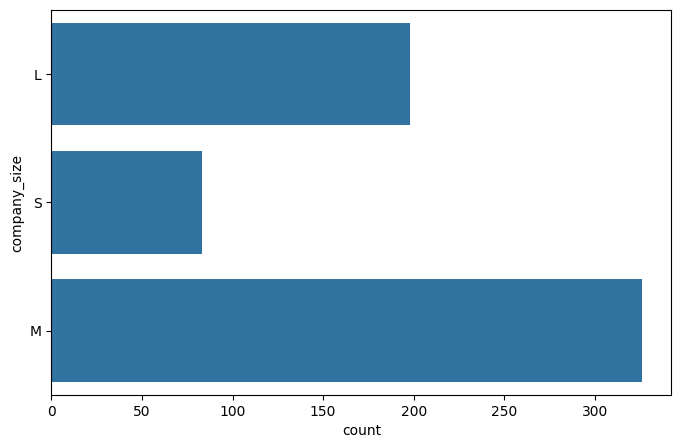

In [219]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.countplot(df['company_size'])
plt.show()

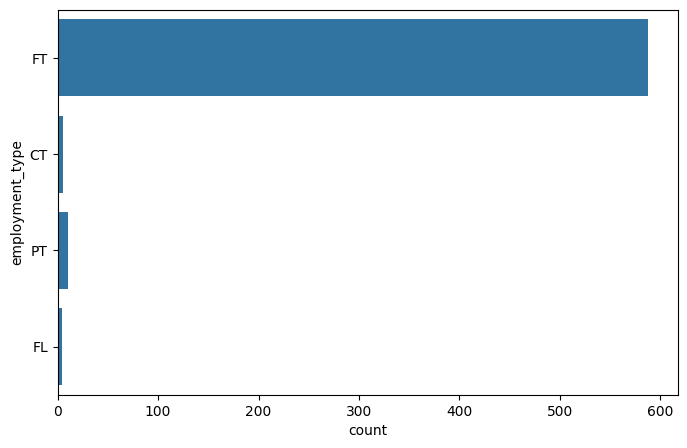

In [220]:
plt.figure(figsize=(8,5))
sns.countplot(df['employment_type'])
plt.show()

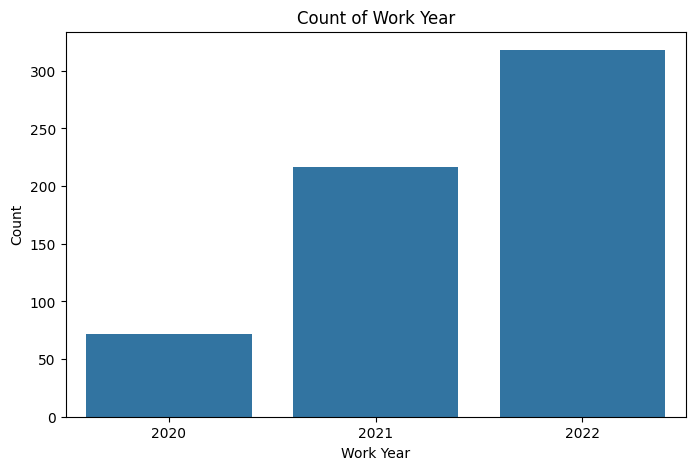

In [221]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x=df['work_year'])
plt.title("Count of Work Year")
plt.xlabel("Work Year")
plt.ylabel("Count")
plt.show()

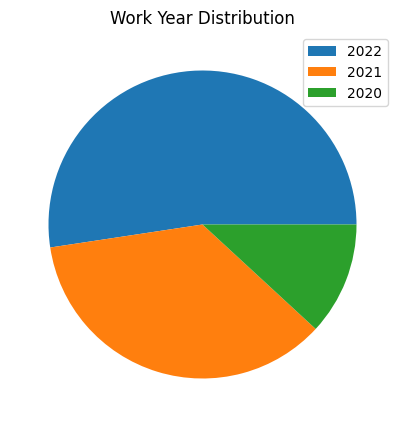

In [222]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
plt.pie(df['work_year'].value_counts())
plt.title("Work Year Distribution")
plt.legend(df['work_year'].value_counts().index)
plt.show()

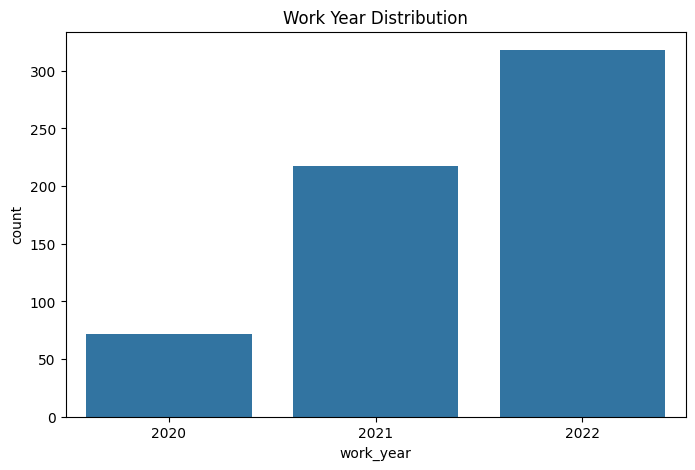

In [223]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='work_year')
plt.title("Work Year Distribution")
plt.show()

#Histplot for All Numerical Columns

In [224]:
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove target
if target in num_cols:
    num_cols.remove(target)

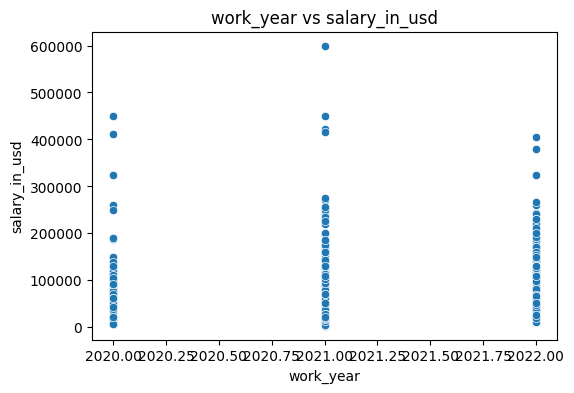

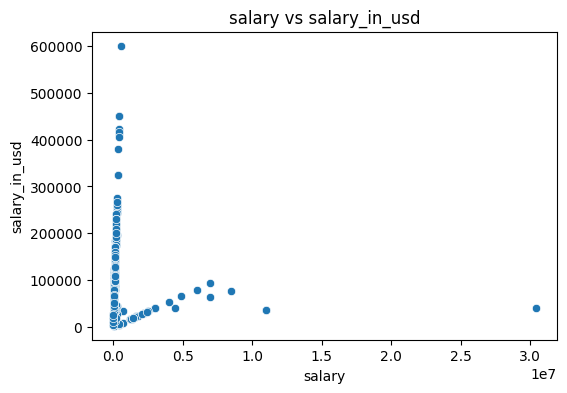

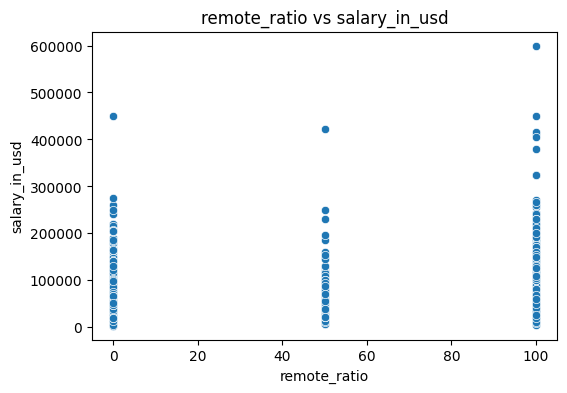

In [225]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=col, y=target)
    plt.title(f'{col} vs {target}')
    plt.show()

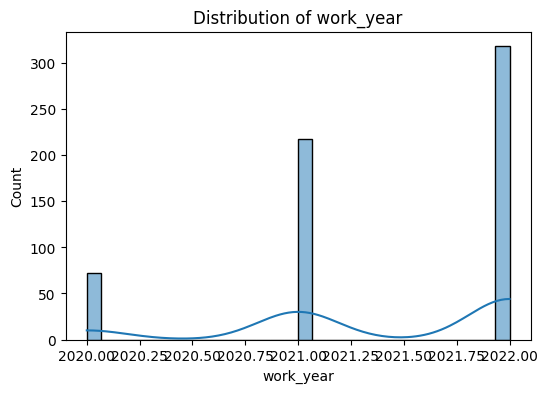

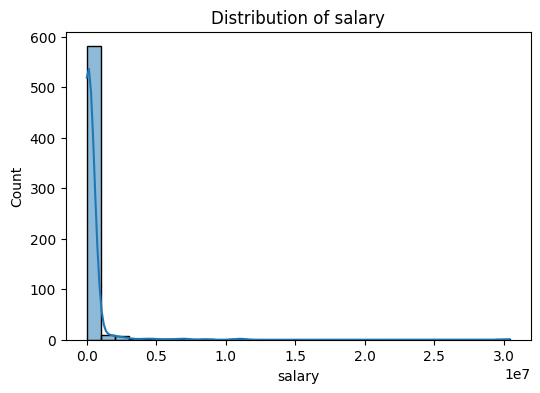

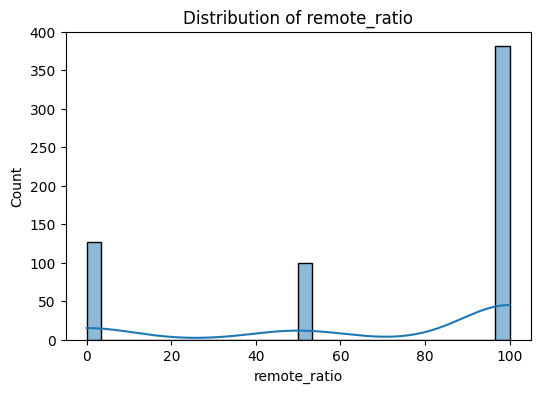

In [226]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remove 'Unnamed: 0' from num_cols if it exists, as it is now the index
if 'Unnamed: 0' in num_cols:
    num_cols.remove('Unnamed: 0')

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

#Salary in usd

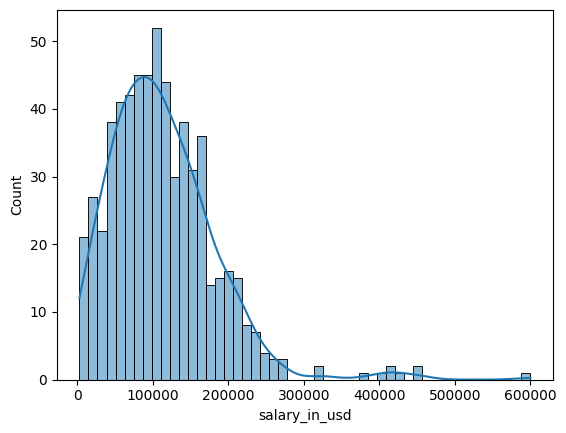

In [227]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['salary_in_usd'], bins=50, kde=True)
plt.show()

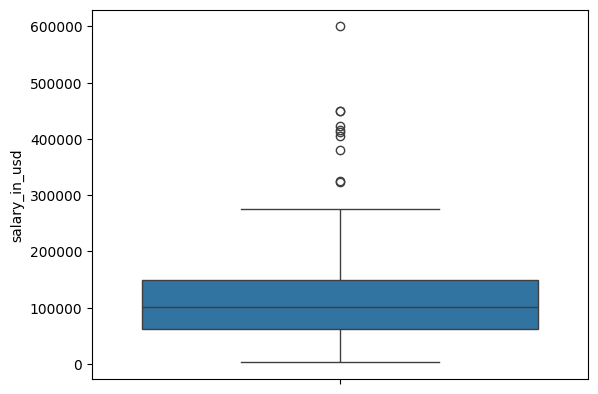

In [228]:
sns.boxplot(df['salary_in_usd'])
plt.show()

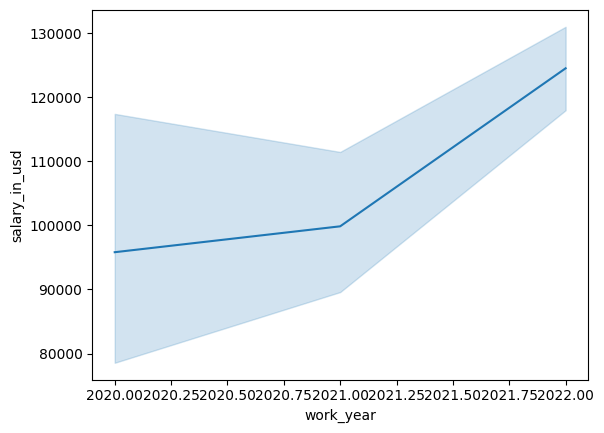

In [229]:
sns.lineplot(x='work_year', y='salary_in_usd', data=df)
plt.show()

#Categorical Columns

#Experience Level

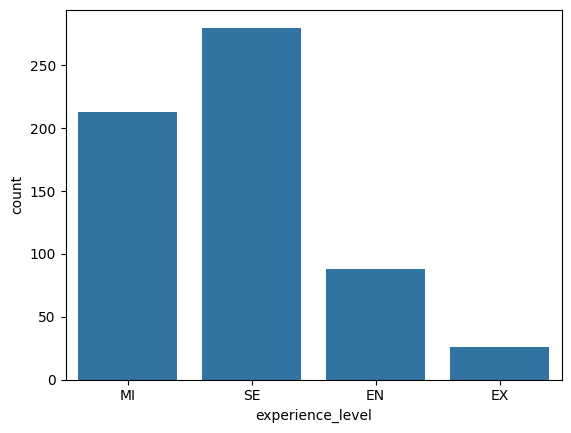

In [230]:
sns.countplot(data=df, x='experience_level')
plt.show()

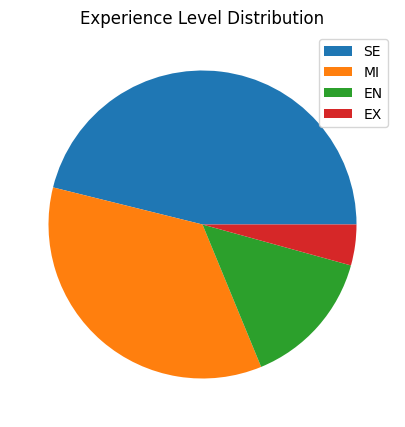

In [231]:
plt.figure(figsize=(8,5))
plt.pie(df['experience_level'].value_counts())
plt.title("Experience Level Distribution")
plt.legend(df['experience_level'].value_counts().index)
plt.show()

#Job_Title

Text(0, 0.5, 'Count')

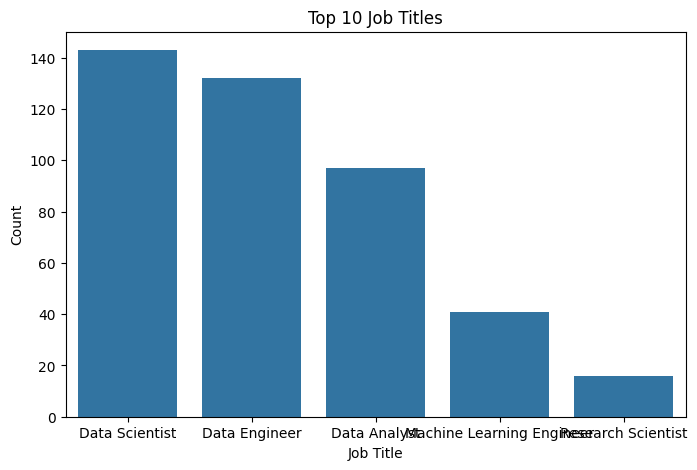

In [232]:
top_jobs = df['job_title'].value_counts().head(5)
plt.figure(figsize=(8,5))
sns.barplot(x=top_jobs.index, y=top_jobs.values)
plt.title("Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")

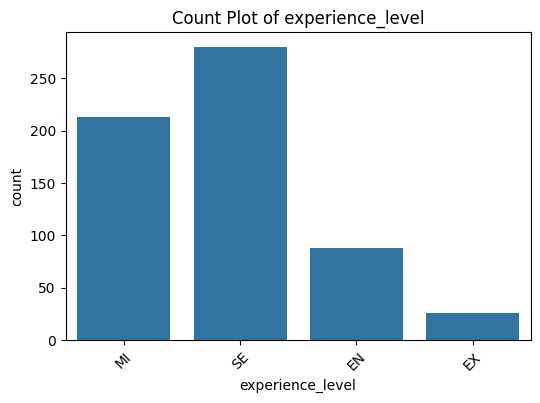

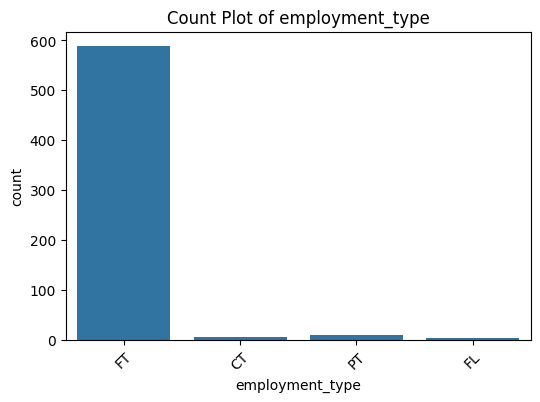

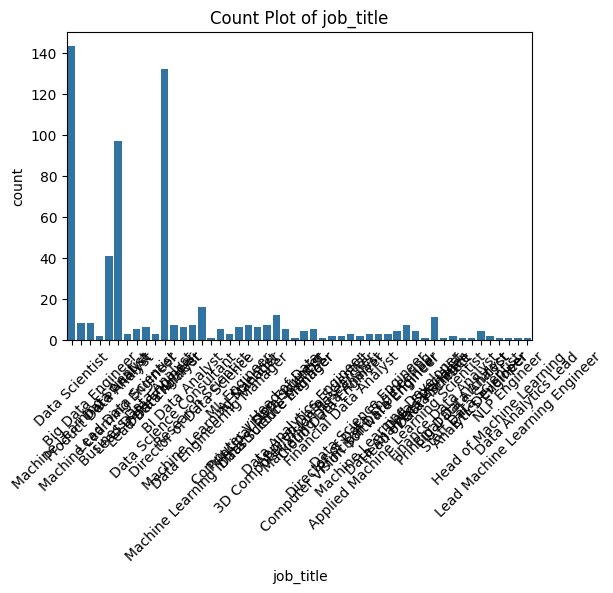

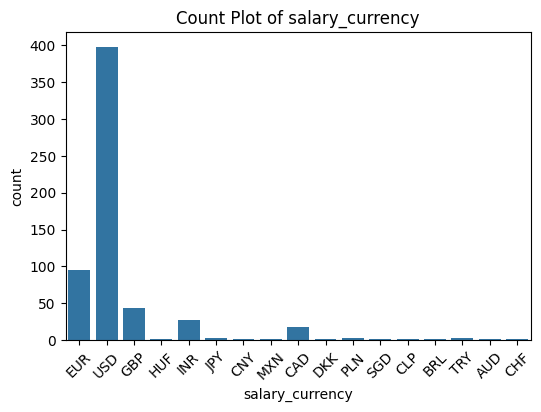

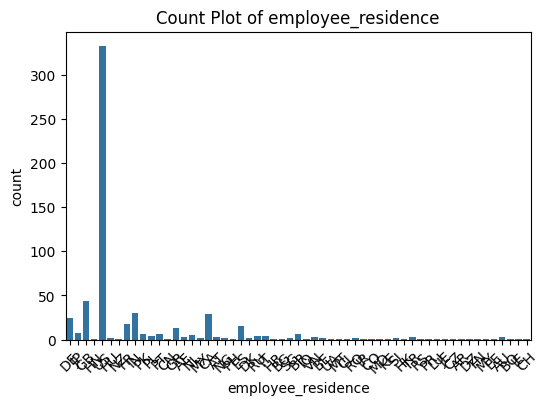

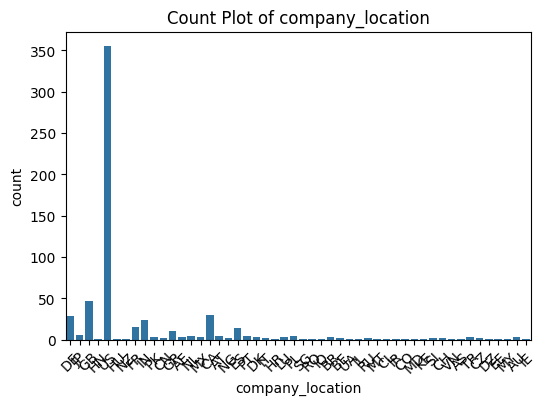

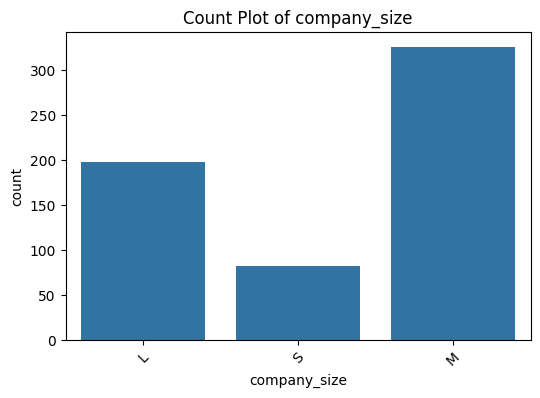

In [233]:
#import seaborn as sns
import matplotlib.pyplot as plt

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()

#Bivariate Analysis

#Categorical vs Numerical (Very Important for ML)

In [234]:
print(cat_cols)

['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']


A. Salary vs Experience Level

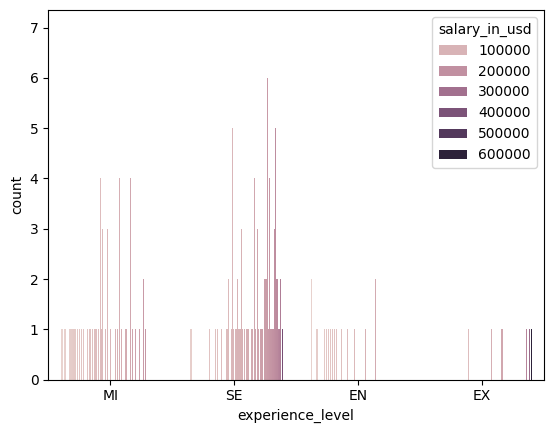

In [235]:
sns.countplot(data=df, x='experience_level',hue='salary_in_usd')
plt.show()

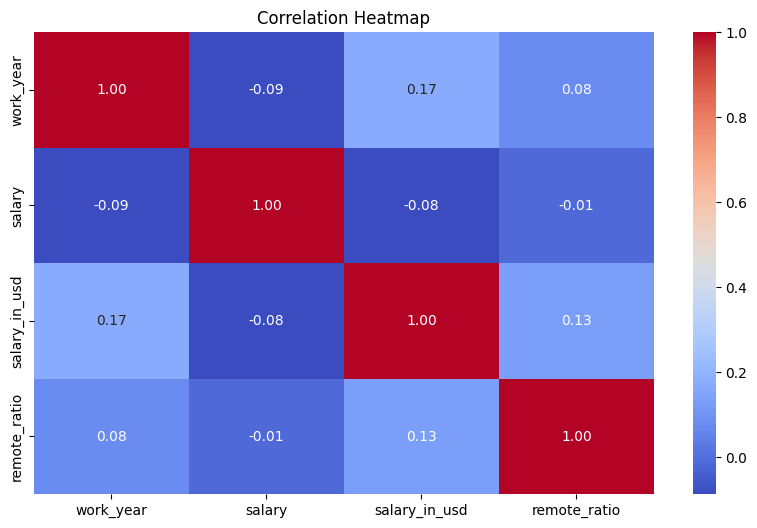

In [236]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

#Job Title vs Salary

In [237]:
top_jobs = df['job_title'].value_counts().head(10).index
df_top = df[df['job_title'].isin(top_jobs)]

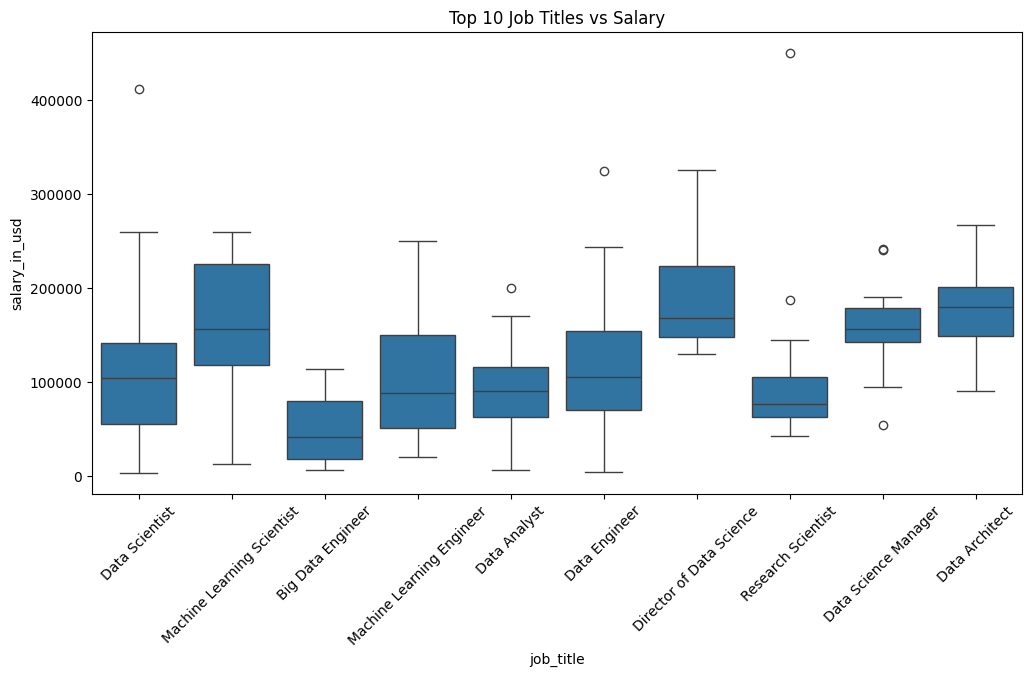

In [238]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(x='job_title', y='salary_in_usd', data=df_top)
plt.xticks(rotation=45)
plt.title('Top 10 Job Titles vs Salary')
plt.show()

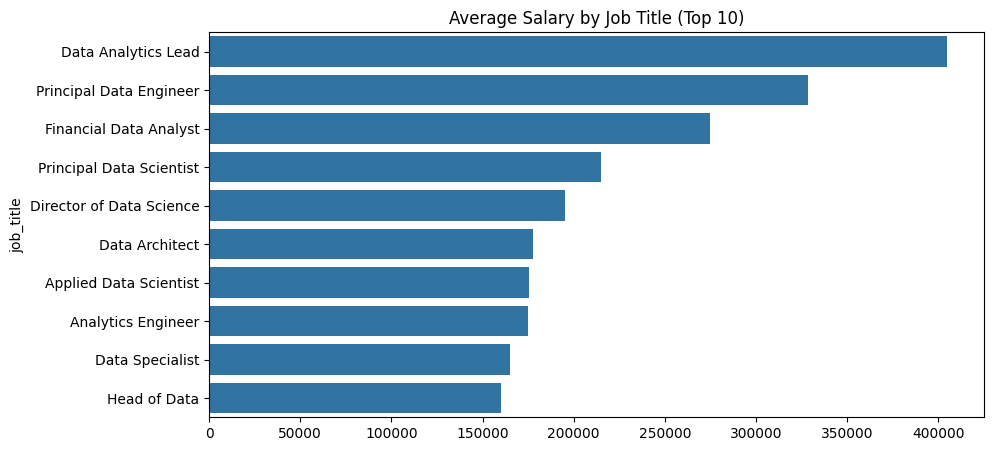

In [239]:
avg_salary = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=avg_salary.values, y=avg_salary.index)
plt.title('Average Salary by Job Title (Top 10)')
plt.show()

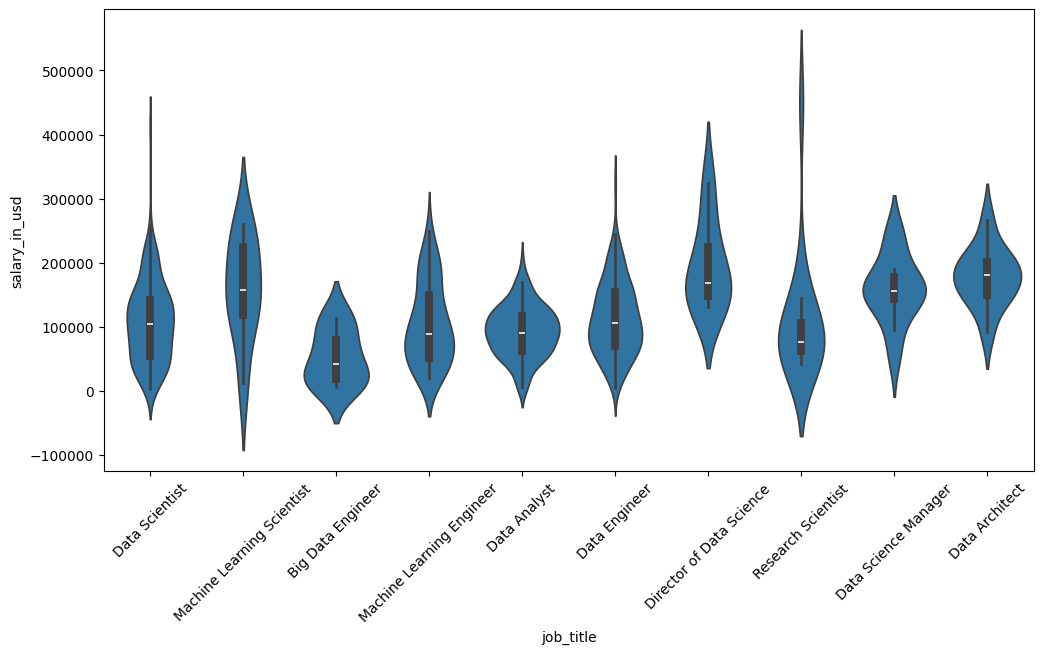

In [240]:
plt.figure(figsize=(12,6))
sns.violinplot(x='job_title', y='salary_in_usd', data=df_top)
plt.xticks(rotation=45)
plt.show()

In [241]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

work_year: 0 outliers
salary: 44 outliers
remote_ratio: 0 outliers


In [242]:
df.drop(columns=['salary'], inplace=True)
target = 'salary_in_usd'

In [243]:
import numpy as np

col = 'salary_in_usd'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[col] = np.where(df[col] < lower, lower, df[col])
df[col] = np.where(df[col] > upper, upper, df[col])

In [244]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [245]:
df.head()

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
index,,,,,,,,,,
0,2020,MI,FT,Data Scientist,EUR,79833.0,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,USD,260000.0,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,GBP,109024.0,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,USD,20000.0,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,USD,150000.0,US,50,US,L


In [246]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical Columns:", cat_cols)

Categorical Columns: ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']


In [247]:
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

experience_level: 4 unique values
employment_type: 4 unique values
job_title: 50 unique values
salary_currency: 17 unique values
employee_residence: 57 unique values
company_location: 50 unique values
company_size: 3 unique values


#Binary Encoding

Experience Level

In [248]:
df['experience_level'].unique()

array(['MI', 'SE', 'EN', 'EX'], dtype=object)

OrdinalEncoder

In [249]:
df['experience_level'] = df['experience_level'].replace({
    'EN': 0,
    'MI': 1,
    'SE': 2,
    'EX': 3
})

/tmp/ipython-input-844/1420647013.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['experience_level'] = df['experience_level'].replace({


In [250]:
df['experience_level'].unique()

array([1, 2, 0, 3])

In [252]:
#It is another way to encode
#from sklearn.preprocessing import OrdinalEncoder

#encoder = OrdinalEncoder(categories=[['EN', 'MI', 'SE', 'EX']])

#df[['experience_level']] = encoder.fit_transform(df[['experience_level']])

Company Size

In [254]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[['S', 'M', 'L']])

df[['company_size']] = encoder.fit_transform(df[['company_size']])

In [255]:
df['company_size'].unique()

array([2., 0., 1.])

In [256]:
df.head()

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
index,,,,,,,,,,
0,2020,1,FT,Data Scientist,EUR,79833.0,DE,0,DE,2.0
1,2020,2,FT,Machine Learning Scientist,USD,260000.0,JP,0,JP,0.0
2,2020,2,FT,Big Data Engineer,GBP,109024.0,GB,50,GB,1.0
3,2020,1,FT,Product Data Analyst,USD,20000.0,HN,0,HN,0.0
4,2020,2,FT,Machine Learning Engineer,USD,150000.0,US,50,US,2.0


In [257]:
df['employment_type'].unique()

array(['FT', 'CT', 'PT', 'FL'], dtype=object)

In [258]:
df = pd.get_dummies(df, columns=['employment_type'], drop_first=True)

In [259]:
df.head()

,work_year,experience_level,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,employment_type_FL,employment_type_FT,employment_type_PT
index,,,,,,,,,,,,
0,2020,1,Data Scientist,EUR,79833.0,DE,0,DE,2.0,False,True,False
1,2020,2,Machine Learning Scientist,USD,260000.0,JP,0,JP,0.0,False,True,False
2,2020,2,Big Data Engineer,GBP,109024.0,GB,50,GB,1.0,False,True,False
3,2020,1,Product Data Analyst,USD,20000.0,HN,0,HN,0.0,False,True,False
4,2020,2,Machine Learning Engineer,USD,150000.0,US,50,US,2.0,False,True,False


In [260]:
print(df.columns)

Index(['work_year', 'experience_level', 'job_title', 'salary_currency',
       'salary_in_usd', 'employee_residence', 'remote_ratio',
       'company_location', 'company_size', 'employment_type_FL',
       'employment_type_FT', 'employment_type_PT'],
      dtype='object')


#Checking Unique Values

In [262]:
print(df['remote_ratio'].unique())
print(df['experience_level'].unique())
print(df['company_size'].unique())
print(df['job_title'].nunique())

[  0  50 100]
[1 2 0 3]
[2. 0. 1.]
50


remote ratio

In [263]:
df['remote_ratio'].value_counts()

,count
remote_ratio,
100,381
0,127
50,99


#➡️ Scaling + Model Training

In [275]:
import numpy as np

df['salary_in_usd'] = np.log1p(df['salary_in_usd'])

In [290]:
target = 'salary_in_usd'

X = df.drop(columns=[target])
y = df[target]

In [291]:
# Drop 'work_year' from X as it was dropped from df and not intended as a feature here.
# If 'work_year' is intended as a feature, this line should be removed or commented out.
if 'work_year' in X.columns:
    X = X.drop(columns=['work_year'])

In [281]:
print(X.shape)
print(y.shape)

(607, 11)
(607,)


In [293]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [283]:
for col in ['job_title', 'employee_residence', 'company_location']:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].map(freq)

In [284]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)

print("SVR R2:", r2_score(y_test, y_pred))

SVR R2: 0.311878823372308


In [285]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled, y_train)

y_pred = ridge.predict(X_test_scaled)
print("Ridge R2:", r2_score(y_test, y_pred))

Ridge R2: 0.6121011882939823


In [294]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [292]:
X = pd.get_dummies(X, columns=['job_title', 'salary_currency', 'employee_residence', 'company_location'], drop_first=True)
print(X.head())

       experience_level  remote_ratio  company_size  employment_type_FL  \
index                                                                     
0                     1             0           2.0               False   
1                     2             0           0.0               False   
2                     2            50           1.0               False   
3                     1             0           0.0               False   
4                     2            50           2.0               False   

       employment_type_FT  employment_type_PT  \
index                                           
0                    True               False   
1                    True               False   
2                    True               False   
3                    True               False   
4                    True               False   

       job_title_0.0032948929159802307  job_title_0.004942339373970346  \
index                                                   

In [272]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1),
    "Lasso": Lasso(alpha=0.1),
    "SVR": SVR(kernel='rbf')
}

In [295]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, rmse, r2])

    print(name)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-"*30)

Linear Regression
RMSE: 0.4842021630326831
R2 Score: 0.6623545005354456
------------------------------
Ridge
RMSE: 0.4859248973177639
R2 Score: 0.6599476205770621
------------------------------
Lasso
RMSE: 0.6163296954828426
R2 Score: 0.45294158731619727
------------------------------
SVR
RMSE: 0.5768262812458449
R2 Score: 0.5208212020644863
------------------------------


In [296]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])
print(results_df.sort_values(by="R2", ascending=False))

               Model      RMSE        R2
0  Linear Regression  0.484202  0.662355
1              Ridge  0.485925  0.659948
3                SVR  0.576826  0.520821
2              Lasso  0.616330  0.452942


#1. R² Comparison Graph

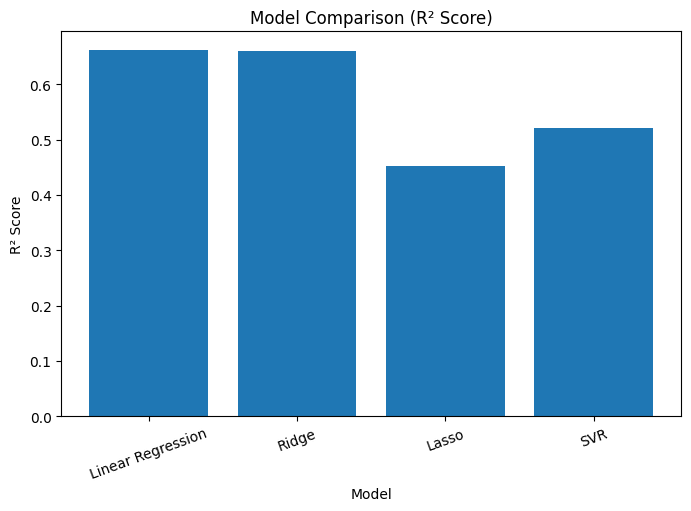

In [297]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['R2'])
plt.title("Model Comparison (R² Score)")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()

#2. RMSE Comparison Graph

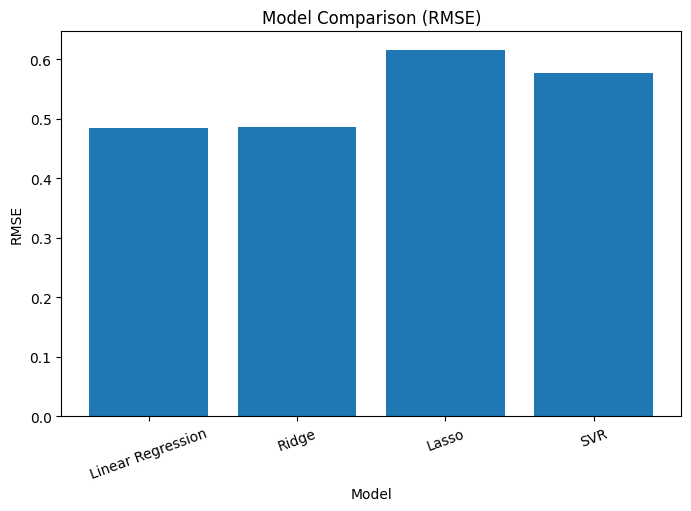

In [298]:
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['RMSE'])
plt.title("Model Comparison (RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()

#3. Actual vs Predicted (Best Model)

In [299]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

ridge = Ridge(alpha=1)
ridge.fit(X_train_scaled, y_train)

y_pred = ridge.predict(X_test_scaled)

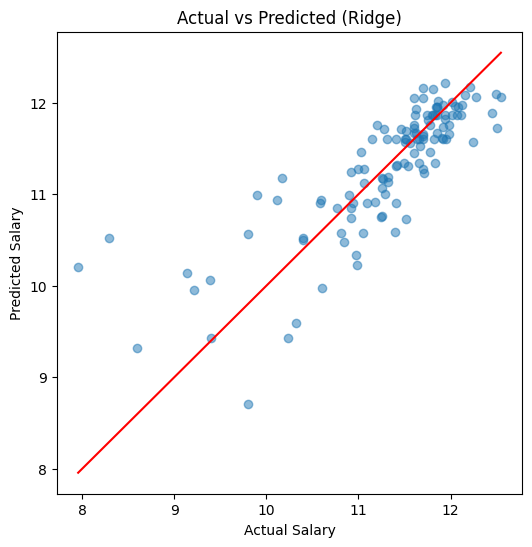

In [300]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted (Ridge)")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()

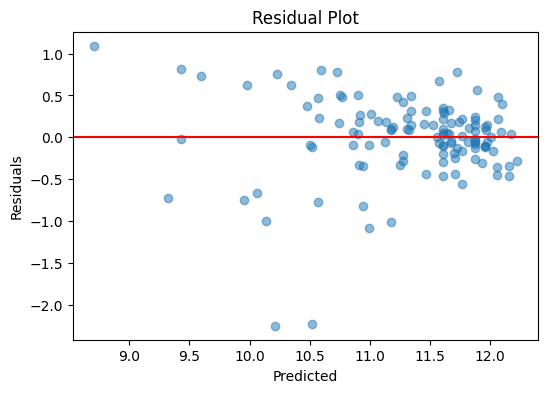

In [301]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()